In [1]:
#Evaluation-of-Perceptual-Hash-Algorithms
#Import das Bibliotecas

import os
import cv2
import hashlib
import imagehash
import matplotlib as mpl

from PIL import Image
from scipy.spatial import *
from matplotlib import pyplot as plot

In [2]:
#Download da Biblioteca para Avaliar algoritmos de Hash Perceptual
#https://pypi.org/project/ImageHash/

In [3]:
#Path Definition
path = 'D:/Google Drive/Github/Evaluation-of-Perceptual-Hash-Algorithms/ImageDatabase/'

In [4]:
#Database Name
database = "MountainDatabase"

In [5]:
#Path Update
path = path + database + "/"

In [6]:
#Extension Type
ext = ".jpg"

In [7]:
#Altered Image Definition
image_name = str(input("Altered Image Name: "))

Altered Image Name: Alternative (4)


In [8]:
#Full Image Name
image_name = image_name + ext
print(image_name)

Alternative (4).jpg


In [9]:
#Import Original and Altered Image
original = cv2.imread(path + 'original.jpg')
alterada = cv2.imread(path + image_name)

In [10]:
#Ordering RGB Layers
original = cv2.cvtColor(original,cv2.COLOR_BGR2RGB)
alterada = cv2.cvtColor(alterada,cv2.COLOR_BGR2RGB)

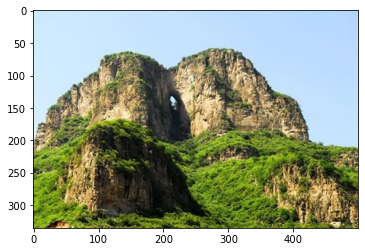

In [11]:
#Original Image
plot.imshow(original,cmap='gray')
plot.show()

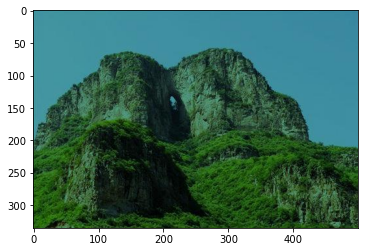

In [12]:
#Altered Image
plot.imshow(alterada,cmap='gray')
plot.show()

In [13]:
#Create a copy of Altered Image to use the Perceptual Hashing
alterada = cv2.cvtColor(alterada,cv2.COLOR_BGR2RGB)
cv2.imwrite(path + 'img2.jpg', alterada);

<b> Conventional Hash Calc: MD5, SHA1 e SHA256 </b>

In [14]:
#Import of binary files
file1 = path + 'original.jpg'
file2 = path + image_name

In [15]:
#File Reading
with open(file1, 'rb') as f1:
    data1 = f1.read()
with open(file2, 'rb') as f2:
    data2 = f2.read()

In [16]:
#Hash Md5, Sha1 and Sha256 Calc
md5_original = str(hashlib.md5(data1).hexdigest())
md5_alterada = str(hashlib.md5(data2).hexdigest())

sha1_original = str(hashlib.sha1(data1).hexdigest())
sha1_alterada = str(hashlib.sha1(data2).hexdigest())

sha256_original = str(hashlib.sha256(data1).hexdigest())
sha256_alterada = str(hashlib.sha256(data2).hexdigest())

<b> Hamming Distance

In [17]:
#Hamming Distance Function
def hamming(hash1,hash2):
    L = len(hash1)
    distance = 0
    
    for i in range(L):
        if hash1[i] != hash2[i]:
            distance += 1

    return(str(distance))

<b> Perceptual Hash - Algorithms</b>

The main Perceptual Hash Types are:
- Average hashing
- Perceptual hashing
- Difference hashing
- Wavelet hashing
- HSV color hashing (ColorHash)
- Crop-resistant hashing

In [18]:
#Average Hashing
ahash1 = str(imagehash.average_hash(Image.open('ImageDatabase/MountainDatabase/original.jpg')))
ahash2 = str(imagehash.average_hash(Image.open('ImageDatabase/MountainDatabase/img2.jpg')))
ahash_dist = hamming(ahash1,ahash2)

In [19]:
#Perceptual Hashing
phash1 = str(imagehash.phash(Image.open('ImageDatabase/MountainDatabase/original.jpg')))
phash2 = str(imagehash.phash(Image.open('ImageDatabase/MountainDatabase/img2.jpg')))
phash_dist = hamming(phash1,phash2)

In [20]:
#Difference Hashing
dhash1 = str(imagehash.dhash(Image.open('ImageDatabase/MountainDatabase/original.jpg')))
dhash2 = str(imagehash.dhash(Image.open('ImageDatabase/MountainDatabase/img2.jpg')))
dhash_dist = hamming(dhash1,dhash2)

In [21]:
#HSV Color Hashing
hsvhash1 = str(imagehash.colorhash(Image.open('ImageDatabase/MountainDatabase/original.jpg')))
hsvhash2 = str(imagehash.colorhash(Image.open('ImageDatabase/MountainDatabase/img2.jpg')))
hsvhash_dist = hamming(hsvhash1,hsvhash2)

In [22]:
#Wavelet Hashing
whash1 = str(imagehash.whash(Image.open('ImageDatabase/MountainDatabase/original.jpg')))
whash2 = str(imagehash.whash(Image.open('ImageDatabase/MountainDatabase/img2.jpg')))
whash_dist = hamming(whash1,whash2)

In [23]:
#Crop-Resistant Hashing
crhash1 = imagehash.crop_resistant_hash(Image.open('ImageDatabase/MountainDatabase/original.jpg'))
crhash2 = imagehash.crop_resistant_hash(Image.open('ImageDatabase/MountainDatabase/img2.jpg'))

ArrayImage01 = str(crhash1).split(',')
ArrayImage02 = str(crhash2).split(',')

if len(ArrayImage01) <= len(ArrayImage02):
    menor = len(ArrayImage01)
    maior = len(ArrayImage02)
    
    total = maior - menor
    for i in range(total):
        ArrayImage01.append('################')
    
elif len(ArrayImage02) < len(ArrayImage01):
    menor = len(ArrayImage02)
    maior = len(ArrayImage01)
    
    total = maior - menor
    for i in range(total):
        ArrayImage02.append('################')

# Results

<b> Conventional Hash Calc: MD5, SHA1 e SHA256 </b>

In [24]:
#Resultados Finais (Arquivos de Hash)
print("\nMD5 Original: " + md5_original)
print("MD5 Alterado: " + md5_alterada)

print("\nSha1 Original: " + sha1_original)
print("Sha1 Alterado: " + sha1_alterada)

print("\nSha256 Original: " + sha256_original)
print("Sha256 Alterado: " + sha256_alterada)


MD5 Original: ee07bb8f2c127818b7937d916625cdec
MD5 Alterado: a85ddefa98380886f22fa12c8f4024e1

Sha1 Original: b568dc0fa979fb62c40abdc34461374590ba8647
Sha1 Alterado: 570b3beabaaaa47a462047e5b0511a02be101571

Sha256 Original: 2f5ef85537cff9955de11644329785588d41699f302f6c0cbd2cdf716d892118
Sha256 Alterado: 5de9e9ffcf2ecd78510f1f5665698531397d7c754d60f9d7c8c9870487343e13


<b> Perceptual Hash Results </b>

In [25]:
#Function to Show the results
def show_perceptual(hash_type,hash1,hash2,distance):
    print("\n" + str(hash_type) + " da Imagem Original: " + str(hash1))
    print(str(hash_type) + " da Imagem Alterada: " + str(hash2))
    print("A distância de Hamming Entre a Imagem Original e a Imagem Alterada é: " + str(distance))    

In [26]:
#Resultados Finais (Hash Perceptual)
show_perceptual("Average Hashing",ahash1,ahash2,ahash_dist)
show_perceptual("Perceptual Hashing",phash1,phash2,phash_dist)
show_perceptual("Difference Hashing",dhash1,dhash2,dhash_dist)
show_perceptual("Wavelet Hashing",whash1,whash2,whash_dist)
show_perceptual("HSV Color Hashing",hsvhash1,hsvhash2,hsvhash_dist)


Average Hashing da Imagem Original: ffffc7cb01000000
Average Hashing da Imagem Alterada: ffffc7cb01000000
A distância de Hamming Entre a Imagem Original e a Imagem Alterada é: 0

Perceptual Hashing da Imagem Original: b9c4c65a8bd15c3c
Perceptual Hashing da Imagem Alterada: b9c4d65a8b515c3c
A distância de Hamming Entre a Imagem Original e a Imagem Alterada é: 2

Difference Hashing da Imagem Original: 402416531b191a1f
Difference Hashing da Imagem Alterada: 402416531b391a1b
A distância de Hamming Entre a Imagem Original e a Imagem Alterada é: 2

Wavelet Hashing da Imagem Original: ffffd7eb8b000000
Wavelet Hashing da Imagem Alterada: ffffd7cb8b800000
A distância de Hamming Entre a Imagem Original e a Imagem Alterada é: 2

HSV Color Hashing da Imagem Original: 03640002000
HSV Color Hashing da Imagem Alterada: 08053001000
A distância de Hamming Entre a Imagem Original e a Imagem Alterada é: 5


<b> Exibição dos Resultados do Hash Perceptual - Crop Resistance Hashing </b>

In [27]:
#Function to show the Results about Crop-Resistance Hashing
total = 0
for i in range(maior):
    print("Crop-Resistant Hashing da Imagem Original: " + str(i + 1) + "ª Redução: " + str(ArrayImage01[i]))
    print("Crop-Resistant Hashing da Imagem Alterada: " + str(i + 1) + "ª Redução: " + str(ArrayImage02[i]))
    
    distance = 0
    string1 = ArrayImage01[i]
    string2 = ArrayImage02[i]
    
    for n in range(len(string1)):        
        if string1[n] != string2[n]:
            distance += 1
    
    total = total + distance
    print("A Distância de Hamming do Crop-Resistant Hashing é: " + str(distance))
    print("\n")

i = i + 1
print("O total das " + str(i) + " Distancias de Hamming do Crop-Resistance é: " + str(total))
print("Dividido por " + str(i) + ": " + str(total/int(i)))

Crop-Resistant Hashing da Imagem Original: 1ª Redução: 00442616175b3b19
Crop-Resistant Hashing da Imagem Alterada: 1ª Redução: 402416531b391a1b
A Distância de Hamming do Crop-Resistant Hashing é: 11


Crop-Resistant Hashing da Imagem Original: 2ª Redução: a5e7b2edccfcfade
Crop-Resistant Hashing da Imagem Alterada: 2ª Redução: ################
A Distância de Hamming do Crop-Resistant Hashing é: 16


Crop-Resistant Hashing da Imagem Original: 3ª Redução: c7d7f13858c4ee02
Crop-Resistant Hashing da Imagem Alterada: 3ª Redução: ################
A Distância de Hamming do Crop-Resistant Hashing é: 16


Crop-Resistant Hashing da Imagem Original: 4ª Redução: 2246cc2d3a56cd91
Crop-Resistant Hashing da Imagem Alterada: 4ª Redução: ################
A Distância de Hamming do Crop-Resistant Hashing é: 16


Crop-Resistant Hashing da Imagem Original: 5ª Redução: 849c4c481e9d2636
Crop-Resistant Hashing da Imagem Alterada: 5ª Redução: ################
A Distância de Hamming do Crop-Resistant Hashing é: 